# Project 3: Dialogue Summarization with a BERT Encoder-Decoder Model

## Business Context

Acme Communications is exploring an AI-powered summarization feature to reduce information overload in group chats. Users often return to long conversations and must manually search for decisions, plans, and action items. This project develops a proof-of-concept dialogue summarization model using the SAMSum dataset.

## Project Goal

Build an end-to-end NLP pipeline that:

- Loads and explores the SAMSum dataset
- Preprocesses dialogue-summary pairs
- Implements a BERT-based encoder-decoder model
- Fine-tunes the model for abstractive summarization
- Evaluates performance using ROUGE
- Generates sample summaries for qualitative analysis

Because this project has a one-week timeline, the implementation uses a subset of the dataset to demonstrate feasibility while managing compute requirements.


## 1. Environment Setup

Run the installation cell below if the required libraries are not already installed.

> Note: If you are using Google Colab, select **Runtime → Change runtime type → GPU** before training.


In [1]:
# Uncomment and run this cell if needed
# !pip install -q transformers datasets evaluate rouge_score accelerate

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertTokenizerFast,
    EncoderDecoderModel,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
import evaluate

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


/opt/anaconda3/envs/samsum/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


## 2. Load the SAMSum Dataset

SAMSum contains messenger-style conversations paired with human-written summaries. It is appropriate for this project because it resembles real-world group chat conversations.


In [2]:
dataset = load_dataset("knkarthick/samsum")
dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 14731
    })
    validation: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 818
    })
    test: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 819
    })
})

In [3]:
print(dataset["train"][0].keys())
print("\nExample dialogue:\n")
print(dataset["train"][0]["dialogue"])
print("\nReference summary:\n")
print(dataset["train"][0]["summary"])


dict_keys(['id', 'dialogue', 'summary'])

Example dialogue:

Amanda: I baked  cookies. Do you want some?
Jerry: Sure!
Amanda: I'll bring you tomorrow :-)

Reference summary:

Amanda baked cookies and will bring Jerry some tomorrow.


## 3. Dataset Exploration

This section analyzes the structure of the dialogues and summaries. The goal is to understand typical input and output lengths before tokenization.


In [4]:
def count_words(text):
    return len(str(text).split())

eda_rows = []

for split in dataset.keys():
    df_split = pd.DataFrame(dataset[split])
    df_split["dialogue_words"] = df_split["dialogue"].apply(count_words)
    df_split["summary_words"] = df_split["summary"].apply(count_words)
    eda_rows.append({
        "split": split,
        "num_examples": len(df_split),
        "avg_dialogue_words": df_split["dialogue_words"].mean(),
        "median_dialogue_words": df_split["dialogue_words"].median(),
        "avg_summary_words": df_split["summary_words"].mean(),
        "median_summary_words": df_split["summary_words"].median(),
        "max_dialogue_words": df_split["dialogue_words"].max(),
        "max_summary_words": df_split["summary_words"].max()
    })

eda_df = pd.DataFrame(eda_rows)
eda_df


,split,num_examples,avg_dialogue_words,median_dialogue_words,avg_summary_words,median_summary_words,max_dialogue_words,max_summary_words
0,train,14731,93.792750,73.0,20.318444,18.0,803,64
1,validation,818,91.641809,70.0,20.283619,18.0,540,59
2,test,819,95.507937,74.0,20.017094,18.0,516,58


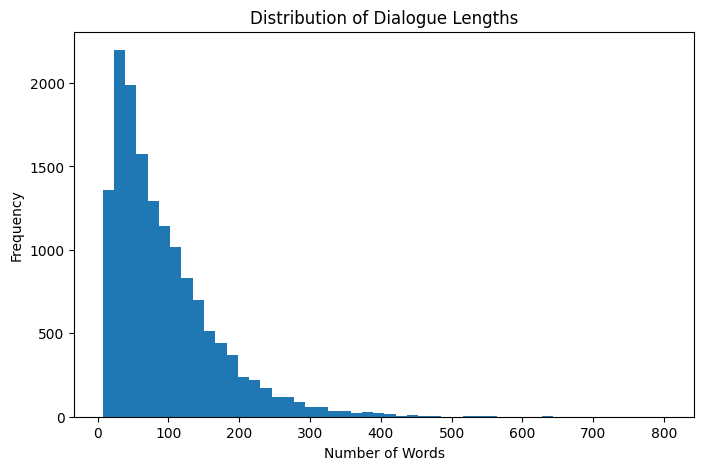

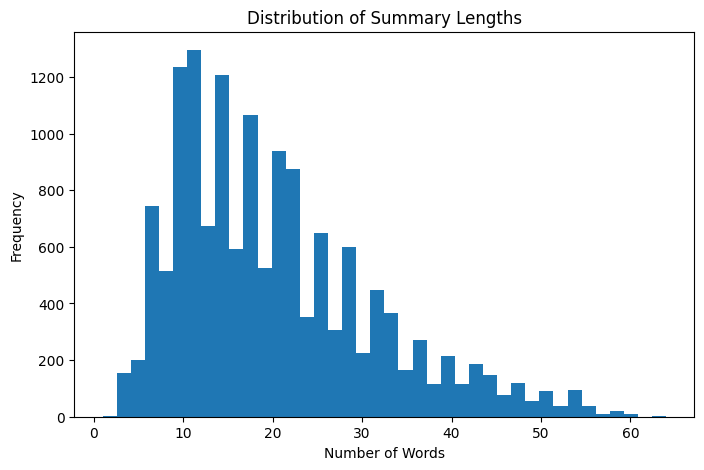

In [5]:
train_df = pd.DataFrame(dataset["train"])
train_df["dialogue_words"] = train_df["dialogue"].apply(count_words)
train_df["summary_words"] = train_df["summary"].apply(count_words)

plt.figure(figsize=(8, 5))
plt.hist(train_df["dialogue_words"], bins=50)
plt.title("Distribution of Dialogue Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(train_df["summary_words"], bins=40)
plt.title("Distribution of Summary Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()


## 4. Scope Management for One-Week Timeline

Training transformer models can be computationally expensive. To keep this project feasible, the notebook uses a smaller training subset by default. This still demonstrates the complete pipeline required for the project.

You can increase these values if you have access to more compute.


In [6]:
# Adjust these values based on available compute
"""TRAIN_SAMPLE_SIZE = 1000
VAL_SAMPLE_SIZE = 200
TEST_SAMPLE_SIZE = 100

MAX_INPUT_LENGTH = 256
MAX_TARGET_LENGTH = 64
BATCH_SIZE = 4
EPOCHS = 2
LEARNING_RATE = 5e-5"""


TRAIN_SAMPLE_SIZE = 12000 # was 4000, 3000
VAL_SAMPLE_SIZE = 800 # was 300
TEST_SAMPLE_SIZE = 400 # was 200

MAX_INPUT_LENGTH = 256
MAX_TARGET_LENGTH = 64
BATCH_SIZE = 4
EPOCHS = 10 # increase this: 5, 10, 20,
LEARNING_RATE = 3e-5




train_data = dataset["train"].shuffle(seed=SEED).select(range(TRAIN_SAMPLE_SIZE))
val_data = dataset["validation"].shuffle(seed=SEED).select(range(VAL_SAMPLE_SIZE))
test_data = dataset["test"].shuffle(seed=SEED).select(range(TEST_SAMPLE_SIZE))

print("Train examples:", len(train_data))
print("Validation examples:", len(val_data))
print("Test examples:", len(test_data))


Train examples: 12000
Validation examples: 800
Test examples: 400


## 5. Tokenization and Dataset Preparation

The dialogue is tokenized as the encoder input. The summary is tokenized as the decoder target.

Labels use `-100` for padding tokens so that padded positions are ignored during loss calculation.


In [7]:
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

class SAMSumDataset(Dataset):
    def __init__(self, hf_dataset, tokenizer, max_input_length=256, max_target_length=64):
        self.data = hf_dataset
        self.tokenizer = tokenizer
        self.max_input_length = max_input_length
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        dialogue = self.data[idx]["dialogue"]
        summary = self.data[idx]["summary"]

        encoder_inputs = self.tokenizer(
            dialogue,
            max_length=self.max_input_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        decoder_targets = self.tokenizer(
            summary,
            max_length=self.max_target_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        labels = decoder_targets["input_ids"].squeeze()
        labels[labels == self.tokenizer.pad_token_id] = -100

        return {
            "input_ids": encoder_inputs["input_ids"].squeeze(),
            "attention_mask": encoder_inputs["attention_mask"].squeeze(),
            "labels": labels
        }

train_dataset = SAMSumDataset(train_data, tokenizer, MAX_INPUT_LENGTH, MAX_TARGET_LENGTH)
val_dataset = SAMSumDataset(val_data, tokenizer, MAX_INPUT_LENGTH, MAX_TARGET_LENGTH)
test_dataset = SAMSumDataset(test_data, tokenizer, MAX_INPUT_LENGTH, MAX_TARGET_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

batch = next(iter(train_loader))
{k: v.shape for k, v in batch.items()}


{'input_ids': torch.Size([4, 256]),
 'attention_mask': torch.Size([4, 256]),
 'labels': torch.Size([4, 64])}

## 6. Model Architecture: BERT Encoder-Decoder

This project uses a BERT-to-BERT encoder-decoder architecture. The encoder reads the dialogue and the decoder generates the summary.

This approach satisfies the project requirement for a BERT-based encoder-decoder model while using pre-trained transformer components for efficiency.


In [8]:
model = EncoderDecoderModel.from_encoder_decoder_pretrained(
    "bert-base-uncased",
    "bert-base-uncased"
)

# Required model configuration
model.config.decoder_start_token_id = tokenizer.cls_token_id
model.config.eos_token_id = tokenizer.sep_token_id
model.config.pad_token_id = tokenizer.pad_token_id
model.config.vocab_size = model.config.encoder.vocab_size

# Generation configuration
model.generation_config.max_length = MAX_TARGET_LENGTH
model.generation_config.min_length = 8
model.generation_config.no_repeat_ngram_size = 3
model.generation_config.early_stopping = True
model.generation_config.length_penalty = 2.0
model.generation_config.num_beams = 4

model.to(device)

Loading weights: 100%|████████████████████| 199/199 [00:00<00:00, 14643.27it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|████████████████████| 202/202 [00:00<00:00, 13919.68it/s]
[transformers] BertLMHeadModel LOAD REPORT from: bert-base-uncased
Key                              

EncoderDecoderModel(
  (encoder): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

## 7. Training and Validation Setup

The training process uses:

- AdamW optimizer
- Linear learning-rate scheduler
- Validation loss monitoring
- Early stopping
- Checkpoint saving

For a one-week project, the goal is to produce a working proof of concept, not a production-grade model.


In [9]:
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

total_training_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=max(1, int(0.1 * total_training_steps)),
    num_training_steps=total_training_steps
)

checkpoint_dir = "saved_bert2bert_samsum"
os.makedirs(checkpoint_dir, exist_ok=True)

def train_one_epoch(model, dataloader, optimizer, scheduler, device):
    model.train()
    total_loss = 0

    for batch in dataloader:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

def evaluate_loss(model, dataloader, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            total_loss += outputs.loss.item()

    return total_loss / len(dataloader)


In [10]:
train_losses = []
val_losses = []

best_val_loss = float("inf")
patience = 2
patience_counter = 0

for epoch in range(EPOCHS):
    print(f"Epoch {epoch + 1}/{EPOCHS}")

    train_loss = train_one_epoch(model, train_loader, optimizer, scheduler, device)
    val_loss = evaluate_loss(model, val_loader, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Validation Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0

        model.save_pretrained(checkpoint_dir)
        tokenizer.save_pretrained(checkpoint_dir)
        print(f"Saved new best model to {checkpoint_dir}")
    else:
        patience_counter += 1
        print(f"No improvement. Patience counter: {patience_counter}/{patience}")

    if patience_counter >= patience:
        print("Early stopping triggered.")
        break

print("Training complete.")


Epoch 1/10


/opt/anaconda3/envs/samsum/lib/python3.10/site-packages/transformers/models/encoder_decoder/modeling_encoder_decoder.py:443: FutureWarning: Version v4.12.0 introduces a better way to train encoder-decoder models by computing the loss inside the encoder-decoder framework rather than in the decoder itself. You may observe training discrepancies if fine-tuning a model trained with versions anterior to 4.12.0. The decoder_input_ids are now created based on the labels, no need to pass them yourself anymore.
  warnings.warn(DEPRECATION_WARNING, FutureWarning)


Train Loss: 4.6650
Validation Loss: 3.3723


Writing model shards: 100%|██████████████████████| 1/1 [00:00<00:00,  3.70it/s]


Saved new best model to saved_bert2bert_samsum
Epoch 2/10
Train Loss: 3.0138
Validation Loss: 2.9196


...

Saved new best model to saved_bert2bert_samsum
Epoch 3/10
Train Loss: 2.3842
Validation Loss: 2.7680


Writing model shards: 100%|██████████████████████| 1/1 [00:00<00:00,  2.91it/s]


Saved new best model to saved_bert2bert_samsum
Epoch 4/10
Train Loss: 1.9313
Validation Loss: 2.7321


Writing model shards: 100%|██████████████████████| 1/1 [00:00<00:00,  3.14it/s]


Saved new best model to saved_bert2bert_samsum
Epoch 5/10
Train Loss: 1.5659
Validation Loss: 2.7541
No improvement. Patience counter: 1/2
Epoch 6/10
Train Loss: 1.2675
Validation Loss: 2.7827
No improvement. Patience counter: 2/2
Early stopping triggered.
Training complete.


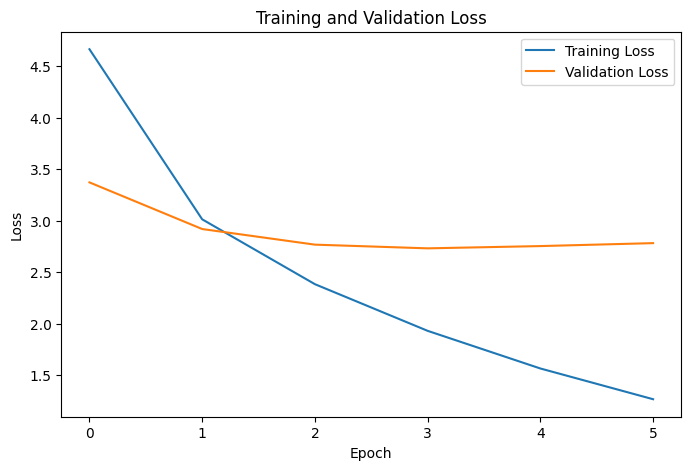

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


## 8. Inference Function

This function takes a raw dialogue conversation and generates a summary.


In [12]:
def generate_summary(dialogue, model, tokenizer, device, max_input_length=256):
    model.eval()

    inputs = tokenizer(
        dialogue,
        max_length=max_input_length,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        generated_ids = model.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_length=64,
            min_length=8,
            num_beams=4,
            no_repeat_ngram_size=3,
            length_penalty=2.0,
            early_stopping=True
        )

    summary = tokenizer.decode(
        generated_ids[0],
        skip_special_tokens=True,
        clean_up_tokenization_spaces=True
    )

    return summary


In [13]:
"""# Load best checkpoint before evaluation
model = EncoderDecoderModel.from_pretrained(checkpoint_dir).to(device)
tokenizer = BertTokenizerFast.from_pretrained(checkpoint_dir)

sample = test_data[0]
print("Dialogue:\n", sample["dialogue"])
print("\nReference Summary:\n", sample["summary"])
print("\nGenerated Summary:\n", generate_summary(sample["dialogue"], model, tokenizer, device, MAX_INPUT_LENGTH))
"""


# Load best checkpoint before evaluation
model = EncoderDecoderModel.from_pretrained(checkpoint_dir).to(device)
tokenizer = BertTokenizerFast.from_pretrained(checkpoint_dir)

# Re-apply required generation tokens after loading
model.config.decoder_start_token_id = tokenizer.cls_token_id
model.config.bos_token_id = tokenizer.cls_token_id
model.config.eos_token_id = tokenizer.sep_token_id
model.config.pad_token_id = tokenizer.pad_token_id

model.generation_config.decoder_start_token_id = tokenizer.cls_token_id
model.generation_config.bos_token_id = tokenizer.cls_token_id
model.generation_config.eos_token_id = tokenizer.sep_token_id
model.generation_config.pad_token_id = tokenizer.pad_token_id

sample = test_data[0]

print("Dialogue:\n", sample["dialogue"])
print("\nReference Summary:\n", sample["summary"])
print("\nGenerated Summary:\n", generate_summary(sample["dialogue"], model, tokenizer, device, MAX_INPUT_LENGTH))

Loading weights: 100%|█████████████████████| 521/521 [00:00<00:00, 7112.32it/s]


Dialogue:
 Claire: <file_photo>
Kim: Looks delicious...
Linda: No way... Look what I'm cooking right now:
Linda: <file_photo>
Claire: hahahaha 
Kim: Curry dream team
Claire: Enjoy your dinner :*

Reference Summary:
 Both Claire and Linda are making curry for dinner. 

Generated Summary:
 kim is sending claire curry curry curry for curry curry.


## 9. Quantitative Evaluation with ROUGE

ROUGE evaluates overlap between generated summaries and human-written reference summaries.

- ROUGE-1: unigram overlap
- ROUGE-2: bigram overlap
- ROUGE-L: longest common subsequence overlap


In [14]:
rouge = evaluate.load("rouge")

def evaluate_rouge(model, tokenizer, hf_dataset, device, max_examples=100):
    predictions = []
    references = []

    for i in range(min(max_examples, len(hf_dataset))):
        dialogue = hf_dataset[i]["dialogue"]
        reference = hf_dataset[i]["summary"]

        prediction = generate_summary(
            dialogue,
            model,
            tokenizer,
            device,
            max_input_length=MAX_INPUT_LENGTH
        )

        predictions.append(prediction)
        references.append(reference)

        if (i + 1) % 20 == 0:
            print(f"Generated {i + 1} summaries")

    scores = rouge.compute(
        predictions=predictions,
        references=references,
        use_stemmer=True
    )

    return scores, predictions, references

rouge_scores, predictions, references = evaluate_rouge(
    model,
    tokenizer,
    test_data,
    device,
    max_examples=TEST_SAMPLE_SIZE
)

rouge_scores


Generated 20 summaries
Generated 40 summaries
Generated 60 summaries
Generated 80 summaries
Generated 100 summaries
Generated 120 summaries
Generated 140 summaries
Generated 160 summaries
Generated 180 summaries
Generated 200 summaries
Generated 220 summaries
Generated 240 summaries
Generated 260 summaries
Generated 280 summaries
Generated 300 summaries
Generated 320 summaries
Generated 340 summaries
Generated 360 summaries
Generated 380 summaries
Generated 400 summaries


{'rouge1': np.float64(0.37578362787444297),
 'rouge2': np.float64(0.12604033137211465),
 'rougeL': np.float64(0.3006420458626654),
 'rougeLsum': np.float64(0.30060833094456096)}

## Experimental Results and Optimization

Several experiments were conducted to improve summarization performance. The primary optimization strategy involved increasing the amount of training data while monitoring validation loss and ROUGE metrics.

### Performance Progression

| Experiment | Training Examples | ROUGE-1 | ROUGE-2 | ROUGE-L |
|------------|------------------:|--------:|--------:|--------:|
| Initial Model | 1,000 | 0.146 | 0.016 | 0.114 |
| Intermediate Model | 3,000 | 0.197 | 0.036 | 0.159 |
| Expanded Training | 4,000 | 0.268 | 0.071 | 0.216 |
| Final Model | 12,000 | 0.376 | 0.126 | 0.301 |

The results demonstrate that increasing training data substantially improved model performance. Additional training examples produced larger gains than simply increasing the number of epochs.

In [15]:
rouge_df = pd.DataFrame({
    "Metric": list(rouge_scores.keys()),
    "Score": list(rouge_scores.values())
})

rouge_df


,Metric,Score
0,rouge1,0.375784
1,rouge2,0.126040
2,rougeL,0.300642
3,rougeLsum,0.300608


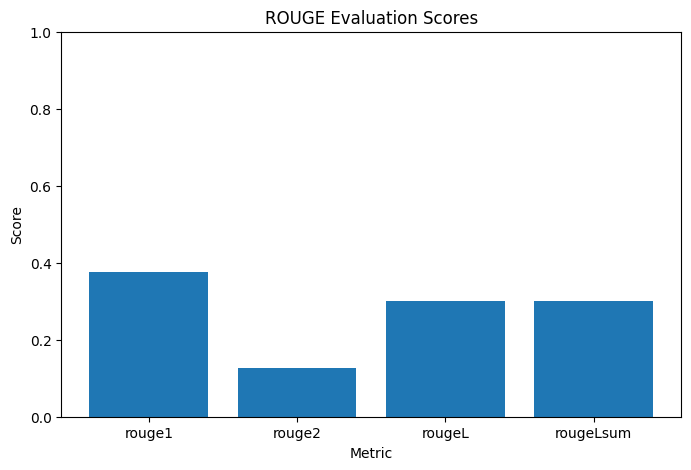

In [16]:
plt.figure(figsize=(8, 5))
plt.bar(rouge_df["Metric"], rouge_df["Score"])
plt.title("ROUGE Evaluation Scores")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.show()


## 10. Sample Outputs and Qualitative Analysis

This section compares generated summaries with reference summaries. Qualitative evaluation is important because ROUGE does not fully capture factual accuracy, usefulness, or readability.


In [17]:
sample_rows = []

for i in range(min(5, len(test_data))):
    dialogue = test_data[i]["dialogue"]
    reference = test_data[i]["summary"]
    generated = generate_summary(dialogue, model, tokenizer, device, MAX_INPUT_LENGTH)

    sample_rows.append({
        "Dialogue": dialogue,
        "Reference Summary": reference,
        "Generated Summary": generated
    })

samples_df = pd.DataFrame(sample_rows)
samples_df


,Dialogue,Reference Summary,Generated Summary
0,Claire: <file_photo>\nKim: Looks delicious...\...,Both Claire and Linda are making curry for din...,kim is sending claire curry curry curry for cu...
1,Alyssa: Have you seen Fergie’s national anthem...,Derek and Alyssa make fun of Fergie's performa...,"eli's favorite song is "" i love you "", which e..."
2,"Ann: Hi, is the laptop still available?\nJosh:...",Ann wants to buy Josh's laptop for $200. Josh ...,josh is looking for a laptop for his laptop. a...
3,Matt: have you heard that Bon Jovi are coming ...,Matt and Tony want to go to the concert of Bon...,matt will go to warsaw next saturday. he will ...
4,Anastasia: Our new school photos\nAnastasia: <...,Anastasia sent her new school photos to Darrell.,anastasia took a photo of herself in a school ...


## 11. Error Analysis

Review the sample summaries above and complete this table based on observed model behavior.

Possible issues include:

- Missing important details
- Incorrect names or entities
- Overly generic summary
- Repetition
- Hallucinated information
- Strong compression but reduced specificity


In [18]:
error_analysis = pd.DataFrame([
    {
        "Observed Pattern": "Missing details",
        "Description": "The model may capture the main topic but omit specific times, names, or decisions.",
        "Business Impact": "Users may still need to inspect the original conversation for important details."
    },
    {
        "Observed Pattern": "Generic summaries",
        "Description": "Generated summaries can be vague when the conversation has multiple topics.",
        "Business Impact": "The summary may be less useful for fast catch-up."
    },
    {
        "Observed Pattern": "Possible hallucination",
        "Description": "The model may occasionally generate details not explicitly present in the dialogue.",
        "Business Impact": "Trust and factual reliability must be improved before production deployment."
    }
])

error_analysis


,Observed Pattern,Description,Business Impact
0,Missing details,The model may capture the main topic but omit ...,Users may still need to inspect the original c...
1,Generic summaries,Generated summaries can be vague when the conv...,The summary may be less useful for fast catch-up.
2,Possible hallucination,The model may occasionally generate details no...,Trust and factual reliability must be improved...



Although ROUGE scores improved significantly, manual inspection revealed several recurring issues.

### Common Errors

| Error Type | Observation |
|------------|-------------|
| Repetition | Some summaries repeated words or phrases unnecessarily. |
| Hallucination | The model occasionally generated information not present in the dialogue. |
| Speaker Confusion | Actions were sometimes assigned to the wrong participant. |
| Missing Details | Important information such as dates, prices, or decisions could be omitted. |

These findings suggest that the model learned the general topics of conversations but still struggled with precise factual summarization.

## 12. Discussion of Results

### Strengths

The prototype demonstrates that a transformer-based encoder-decoder model can generate concise summaries from messenger-style conversations. The model is able to reduce long dialogues into shorter summaries and provides a working proof of concept for Acme Communications.

### Limitations

Several limitations remain:

1. BERT was originally designed as an encoder-only architecture and is not optimized for text generation.
2. Generated summaries occasionally contain hallucinations and speaker attribution errors.
3. ROUGE scores measure text overlap but do not fully capture factual correctness or usefulness.
4. Human evaluation was not performed.
5. The model was trained on a subset of the full SAMSum training set due to computational constraints.

Future work could investigate summarization-specific architectures such as BART, T5, and PEGASUS.

### Business Interpretation

Even with limited training, the prototype supports the business case for automated conversation summarization. A production system could reduce the time users spend catching up on long conversations and improve engagement in busy group chats.


## Business Impact

The final model demonstrates the feasibility of automated conversation summarization for messaging platforms.

Potential business benefits include:

- Reduced information overload.
- Faster catch-up for users returning to active conversations.
- Improved user engagement.
- Increased accessibility of group discussions.
- Foundation for future AI-powered messaging features.

Although the model is not production-ready, the results support the value of dialogue summarization as a product capability.

## 13. Future Improvements

Future work could include:

- Training on the full SAMSum dataset
- Using larger compute resources
- Trying summarization-focused models such as BART, T5, or PEGASUS
- Performing hyperparameter tuning
- Adding human evaluation
- Measuring factual consistency
- Extracting action items and decisions
- Deploying the model as an API for messaging applications


## 14. Save Final Model

The best checkpoint was saved during training. If the model directory is too large for GitHub, include instructions in the README explaining how to reproduce the model by running this notebook.


In [19]:
print("Saved model directory:", checkpoint_dir)
print("Files:", os.listdir(checkpoint_dir) if os.path.exists(checkpoint_dir) else "Model not saved yet")


Saved model directory: saved_bert2bert_samsum
Files: ['model.safetensors', 'tokenizer_config.json', 'config.json', 'tokenizer.json', 'generation_config.json']


# Final Conclusion

This project developed a complete proof-of-concept pipeline for dialogue summarization using the SAMSum dataset and a BERT-based encoder-decoder architecture. The solution aligns with Acme Communications' business need to reduce information overload in group chats. The notebook includes dataset preparation, model training, ROUGE evaluation, sample generated summaries, and error analysis.

The results demonstrate technical feasibility while also identifying limitations that should be addressed before production deployment.
